In [1]:
import numpy as np
import pandas as pd
import os,sys
import glob
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.
Could not save font_manager cache [Errno 122] Disk quota exceeded: '/mnt/lcars/home/h/haoershi/.cache/matplotlib/fontlist-v390.json.matplotlib-lock'


In [2]:
%pwd

'/mnt/sauce/littlab/users/haoershi/emu_dataset'

In [3]:
%cd ../limited_montage

/mnt/sauce/littlab/users/haoershi/limited_montage


/mnt/leif/littlab/users/haoershi/.venv/lib64/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
montage_dict = {'full':['Fp1-F7', 'F7-T3', 'T3-T5', 'T5-O1', 'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2', 
                        'Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2'],
                'uneeg_left_front':['F7-T3'],
                'uneeg_left_back':['T3-T5'],
                'uneeg_right_front':['F8-T4'],
                'uneeg_right_back':['T4-T6'],
                'uneeg_right':['F8-T4','T4-T6'],
                'uneeg_left':['F7-T3','T3-T5'],
                'uneeg_right':['F8-T4','T4-T6'],
                'uneeg_bilateral_back2':['T3-T5','T4-T6'],
                'uneeg_bilateral_front2':['F7-T3','F8-T4'],
                'uneeg_vert_left':['C3-T3'],
                'uneeg_vert_right':['C4-T4'],
                'uneeg_diag_left_front':['F3-T3'],
                'uneeg_diag_left_back':['P3-T3'],
                'uneeg_diag_right_front':['F4-T4'],
                'uneeg_diag_right_back':['P4-T4'],
                'epiminder_2':['C3-P3','C4-P4']}
montage_list = list(montage_dict.keys())
channel_map = {
    'Fp1':['left','frontal'],
    'F3':['left','frontal'],
    'F7':['left','temporal'],
    'C3':['left','central'],
    'P3':['left','parietal'],
    'T3':['left','temporal'],
    'T5':['left','temporal'],
    'O1':['left','occipital'],
    'Fp2':['right','frontal'],
    'F4':['right','frontal'],
    'F8':['right','temporal'],
    'C4':['right','central'],
    'P4':['right','parietal'],
    'T4':['right','temporal'],
    'T6':['right','temporal'],
    'O2':['right','occipital'],
}

result_dir = '/mnt/sauce/littlab/users/joekoji/montage-proj/dynasd_results_fixed/prob'
sz_details = pd.read_csv('../emu_dataset/ueoeec_seizure_events_2017_2024.csv')
sz_details2 = pd.read_csv('../emu_dataset/ueoeec_seizure_details.csv')
sz_details = sz_details2.merge(sz_details[['event_patient_id','start','end']], on='event_patient_id', how = 'left')
admission_info = pd.read_csv('../emu_dataset/dataset_admission_info.csv').rename(columns={'laterality':'pat_lat','location':'pat_loc'})
sz_details = sz_details.merge(admission_info, left_on='patient',right_on='admission_id', how='left')

In [6]:
sz_details_lat['epilepsy_type'].value_counts()

epilepsy_type
focal    964
Name: count, dtype: int64

In [5]:
sz_details_lat = sz_details[(~sz_details['laterality'].isna()) | (~sz_details['region'].isna())]
sz_details_lat = sz_details_lat[sz_details_lat['epilepsy_type']=='focal']

In [7]:
montage = 'full'

In [ ]:
for i, row in sz_details_lat.iloc[:20].iterrows():
    prob_file = f"{result_dir}/{montage}/{row['event_patient_id']}.csv"
    try:
        prob = pd.read_csv(prob_file,index_col=0)
    except:
        continue
    prob = prob[[c for c in prob.columns if c.startswith('prob')]].rename(columns={c:c.strip('prob_') for c in prob.columns})
    sz_onset = row['ueoeec']-row['start']
    sz_offset = row['off']-row['start']
    fig, ax = plt.subplots(figsize=(15,5))
    ax.matshow(prob.T,aspect='auto',vmin=0,vmax=np.percentile(prob.values,95))
    # ax.set_xticks(range(prob.shape[0]), np.linspace(0,0.5*prob.shape[0],endpoint=False))
    xticks = ax.get_xticks()
    xtick_labels = [str(int(x/2)) for x in xticks]
    ax.set_xticklabels(xtick_labels)
    ax.set_yticks(range(prob.shape[1]), list(prob.columns))
    ax.vlines([sz_onset*2,sz_offset*2],ymin=0,ymax=prob.shape[1]-1, color='r')
    ax.text(0.9,0.9,f"{row['laterality']}\n{row['region']}")
    if not pd.isna(row['channels']):
        fig.text(0.127,0.78,f"{row['channels']}")
    plt.show()
    fig.savefig(f"sz_loc_figures/{row['event_patient_id']}.png",dpi=200)
    plt.close()

In [8]:
def symmetric_decay_mean_all_columns(df, half_life_seconds):
    t = df.index.to_numpy(dtype=float)
    decay_rate = np.log(2) / half_life_seconds
    weights = np.exp(-decay_rate * np.abs(t))  # vector of weights

    # Weighted average per column
    return (df.mul(weights, axis=0).sum(axis=0)) / weights.sum()

from collections import Counter

In [9]:
for i, row in sz_details_lat.iterrows():
    prob_file = f"{result_dir}/{montage}/{row['event_patient_id']}.csv"
    try:
        prob = pd.read_csv(prob_file,index_col=0)
    except:
        continue
    prob = prob[[c for c in prob.columns if c.startswith('prob')]].rename(columns={c:c.strip('prob_') for c in prob.columns})
    prob.index = pd.to_datetime(prob.index)
    prob.index = (prob.index-prob.index[0]).total_seconds()
    sz_onset = row['ueoeec']-row['start']
    sz_offset = row['off']-row['start']
    prob.index = prob.index-sz_onset
    prob_start = prob[(prob.index>=-5)&(prob.index<=20)]
    weighted_means = symmetric_decay_mean_all_columns(prob_start, 4)
    weighted_means = weighted_means.sort_values(ascending=False)
    onset_channels = weighted_means[:3].index.to_list()
    onset_channels = [c.split('-')[0] for c in onset_channels]
    lat = [channel_map[c][0] for c in onset_channels]
    counter = Counter(lat)
    max_count = max(counter.values())
    lat = [k for k, v in counter.items() if v == max_count]
    region = list(set([r  for c in onset_channels for r in channel_map[c][1:]]))
    sz_details_lat.loc[i,'ndd_lat'] = ','.join(lat)
    sz_details_lat.loc[i,'ndd_region'] = ','.join(region)
sz_details_lat.to_csv('sz_details_ndd_annot_comp.csv',index=False)

In [15]:
for i, row in sz_details_lat.iterrows():
    prob_file = f"{result_dir}/{montage}/{row['event_patient_id']}.csv"
    try:
        prob = pd.read_csv(prob_file,index_col=0)
    except:
        continue
    prob = prob[[c for c in prob.columns if c.startswith('prob')]].rename(columns={c:c.strip('prob_') for c in prob.columns})
    prob = np.log(prob)
    prob.index = pd.to_datetime(prob.index)
    prob.index = (prob.index-prob.index[0]).total_seconds()
    sz_onset = row['ueoeec']-row['start']
    sz_offset = row['off']-row['start']
    prob.index = prob.index-sz_onset
    prob_start = prob[(prob.index>=0)&(prob.index<=20)]
    # weighted_means = symmetric_decay_mean_all_columns(prob_start, 5)
    weighted_means = prob_start.median(axis=0)
    left_means = weighted_means.loc[['Fp1-F7', 'F7-T3', 'T3-T5', 'T5-O1','Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1']].mean()
    right_means = weighted_means.loc[['Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2','Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2']].mean()
    onset_channels = [weighted_means.index[0]]#.to_list()
    onset_channels = [c.split('-')[0] for c in onset_channels]
    lat = [channel_map[c][0] for c in onset_channels]
    counter = Counter(lat)
    max_count = max(counter.values())
    lat = [k for k, v in counter.items() if v == max_count]
    region = list(set([r  for c in onset_channels for r in channel_map[c][1:]]))
    sz_details_lat.loc[i,'ndd_lat'] = 'left' if left_means > right_means else 'right'
    sz_details_lat.loc[i,'ndd_region'] = ','.join(region)
sz_details_lat.to_csv('sz_details_ndd_annot_comp.csv',index=False)

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score
import seaborn as sns

In [ ]:
lat_comp = sz_details_lat[(~sz_details_lat['laterality'].isna())&(~sz_details_lat['ndd_lat'].isna())]
labels = sorted(lat_comp["laterality"].unique())  # ensures consistent order
cm = confusion_matrix(lat_comp["laterality"], lat_comp["ndd_lat"], labels=labels)
acc = accuracy_score(lat_comp["laterality"], lat_comp["ndd_lat"])
print("Accuracy:", acc)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Accuracy: 0.6254980079681275


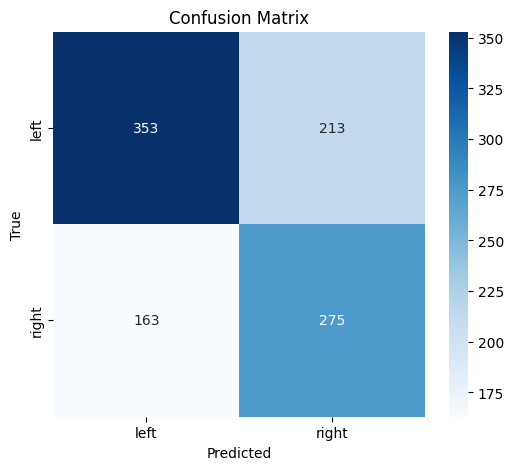

In [16]:
lat_comp = sz_details_lat[(~sz_details_lat['laterality'].isna())&(~sz_details_lat['ndd_lat'].isna())]
labels = sorted(lat_comp["laterality"].unique())  # ensures consistent order
cm = confusion_matrix(lat_comp["laterality"], lat_comp["ndd_lat"], labels=labels)
acc = accuracy_score(lat_comp["laterality"], lat_comp["ndd_lat"])
print("Accuracy:", acc)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Accuracy: 0.6364749082007344


/tmp/ipykernel_34340/370199474.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_comp[region] = region_comp['region'].str.contains(region)
/tmp/ipykernel_34340/370199474.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_comp['ndd_'+region] = region_comp['ndd_region'].str.contains(region)


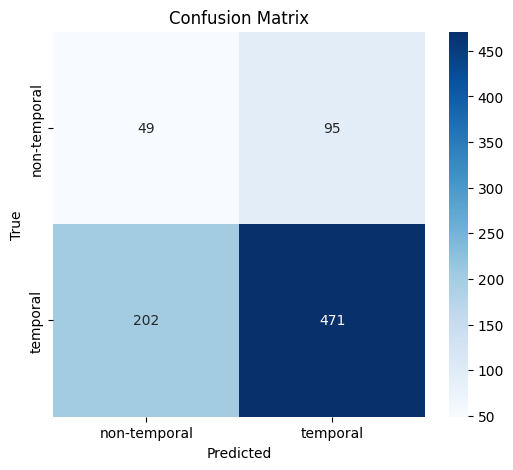

/tmp/ipykernel_34340/370199474.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_comp[region] = region_comp['region'].str.contains(region)
/tmp/ipykernel_34340/370199474.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_comp['ndd_'+region] = region_comp['ndd_region'].str.contains(region)


Accuracy: 0.7050183598531212


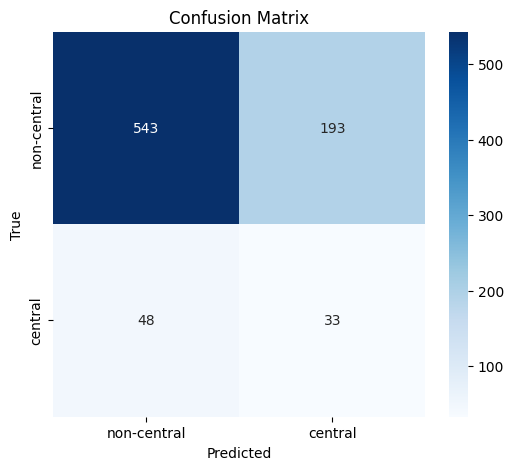

/tmp/ipykernel_34340/370199474.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_comp[region] = region_comp['region'].str.contains(region)
/tmp/ipykernel_34340/370199474.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_comp['ndd_'+region] = region_comp['ndd_region'].str.contains(region)


Accuracy: 0.3427172582619339


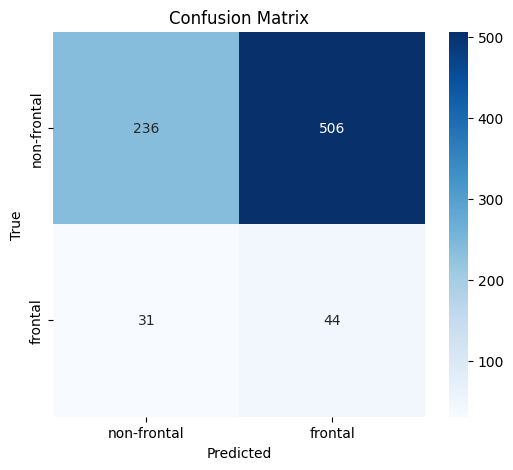

In [12]:
region_comp = sz_details_lat[(~sz_details_lat['region'].isna())&(~sz_details_lat['ndd_region'].isna())]
for region in ['temporal','central','frontal']:
    labels = ['non-'+region,region]
    region_comp[region] = region_comp['region'].str.contains(region)
    region_comp['ndd_'+region] = region_comp['ndd_region'].str.contains(region)
    cm = confusion_matrix(region_comp[region], region_comp['ndd_'+region])
    acc = accuracy_score(region_comp[region], region_comp['ndd_'+region])
    print("Accuracy:", acc)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()